# BÀI TẬP 3 - CNN: Nhận dạng Fashion-MNIST
**Dataset:** Fashion-MNIST (built-in TensorFlow/Keras)
**Labels:** T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot

In [1]:
# BƯỚC 1: NẠP THƯ VIỆN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [2]:
# BƯỚC 2: ĐỌC DỮ LIỆU FASHION MNIST
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']
num_classes = 10
input_shape = (28, 28, 1)

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize & reshape cho CNN (thêm channel)
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test  = X_test.reshape(X_test.shape[0],  28, 28, 1)

# One-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print('X_train:', X_train.shape)
print('y_train[:5]:', y_train[:5])
print('Number of classes:', num_classes)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train: (60000, 28, 28, 1)
y_train[:5]: [9 0 0 3 0]
Number of classes: 10


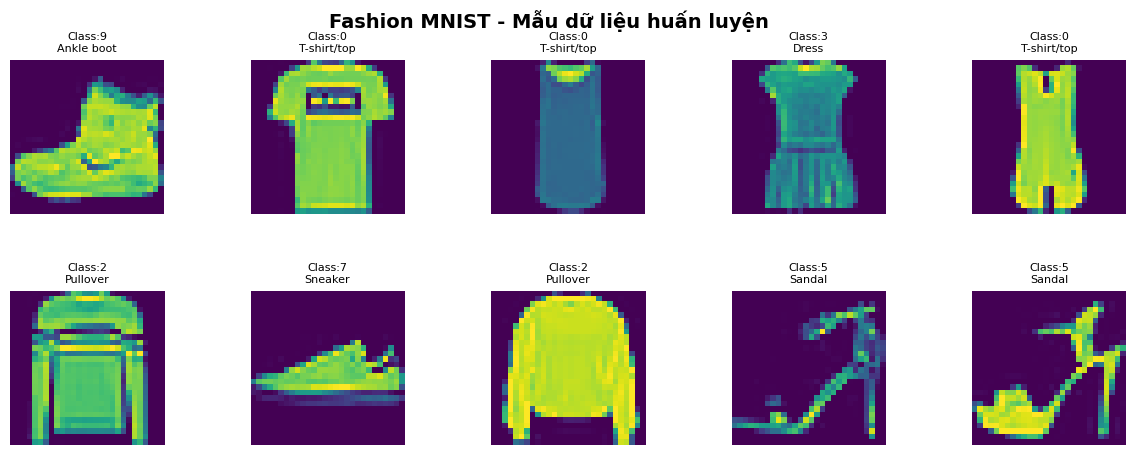

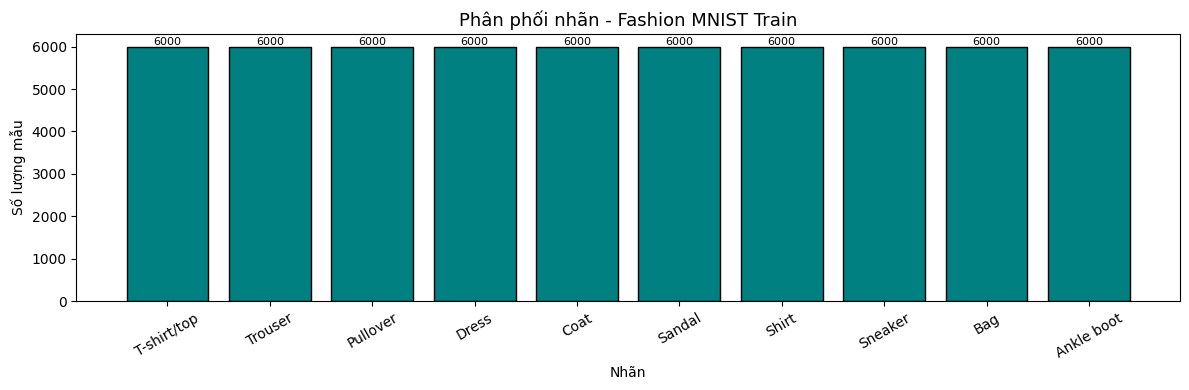

In [3]:
# BƯỚC 3: TRỰC QUAN HÓA 10 ẢNH ĐẦU TIÊN
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='viridis')
    axes[i].set_title(f'Class:{y_train[i]}\n{class_names[y_train[i]]}', fontsize=8)
    axes[i].axis('off')
plt.suptitle('Fashion MNIST - Mẫu dữ liệu huấn luyện', fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.5)
plt.show()

# Phân phối nhãn
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(12, 4))
bars = plt.bar([class_names[i] for i in unique], counts, color='teal', edgecolor='black')
for bar, cnt in zip(bars, counts):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, str(cnt), ha='center', fontsize=8)
plt.title('Phân phối nhãn - Fashion MNIST Train', fontsize=13)
plt.xlabel('Nhãn'); plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [4]:
# BƯỚC 4: XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Input(shape=input_shape),
    Conv2D(32, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# BƯỚC 5: HUẤN LUYỆN MÔ HÌNH
model_fit = model.fit(X_train, y_train_cat,
                      validation_split=0.1,
                      epochs=15,
                      batch_size=128,
                      verbose=1)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 50s 115ms/step - accuracy: 0.7740 - loss: 0.6234 - val_accuracy: 0.8463 - val_loss: 0.4153
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.8566 - loss: 0.4031 - val_accuracy: 0.8707 - val_loss: 0.3445
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.8740 - loss: 0.3492 - val_accuracy: 0.8807 - val_loss: 0.3184
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.8844 - loss: 0.3160 - val_accuracy: 0.8907 - val_loss: 0.2943
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.8936 - loss: 0.2921 - val_accuracy: 0.8983 - val_loss: 0.2799
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9020 - loss: 0.2731 - val_accuracy: 0.8997 - val_loss: 0.2745
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 103ms/step - accuracy: 0.9053 - loss: 0.2604 - val_accuracy: 0.9037 - val_loss: 0.2615
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - accuracy: 0.9091 - loss: 0.244

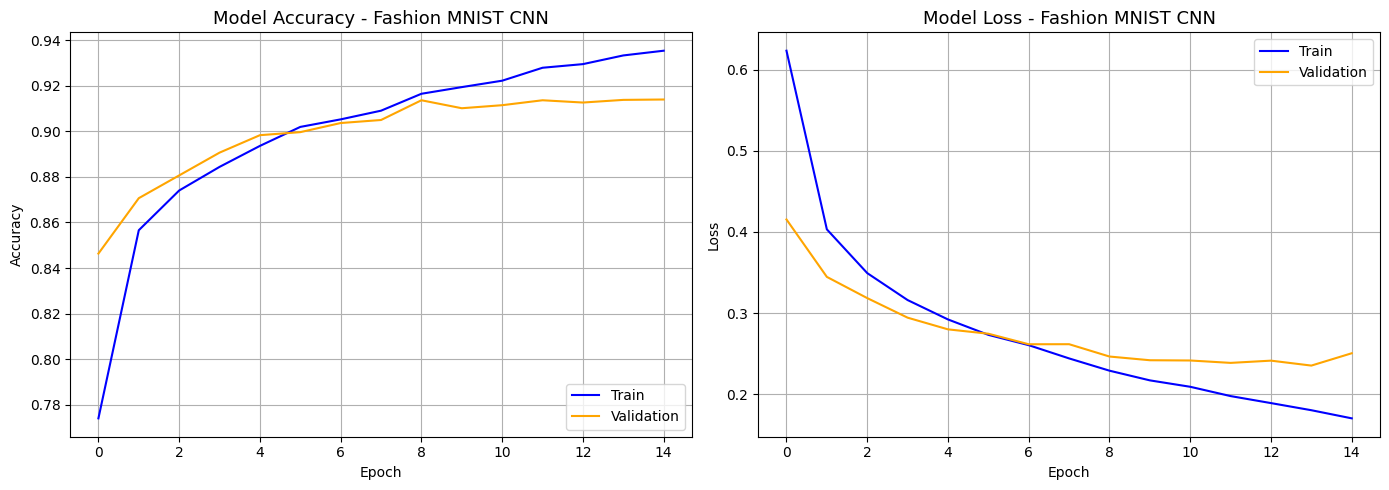

In [6]:
# BƯỚC 6: BIỂU ĐỒ ACCURACY & LOSS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_fit.history['accuracy'], label='Train', color='blue')
axes[0].plot(model_fit.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy - Fashion MNIST CNN', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right'); axes[0].grid(True)

axes[1].plot(model_fit.history['loss'], label='Train', color='blue')
axes[1].plot(model_fit.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss - Fashion MNIST CNN', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right'); axes[1].grid(True)

plt.tight_layout(); plt.show()

313/313 - 3s - 8ms/step - accuracy: 0.9100 - loss: 0.2663
Test loss:     0.2663053572177887
Test accuracy: 0.9100000262260437
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step

=== Classification Report ===
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.90      0.81      0.85      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.80      0.93      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.77      0.71      0.74      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



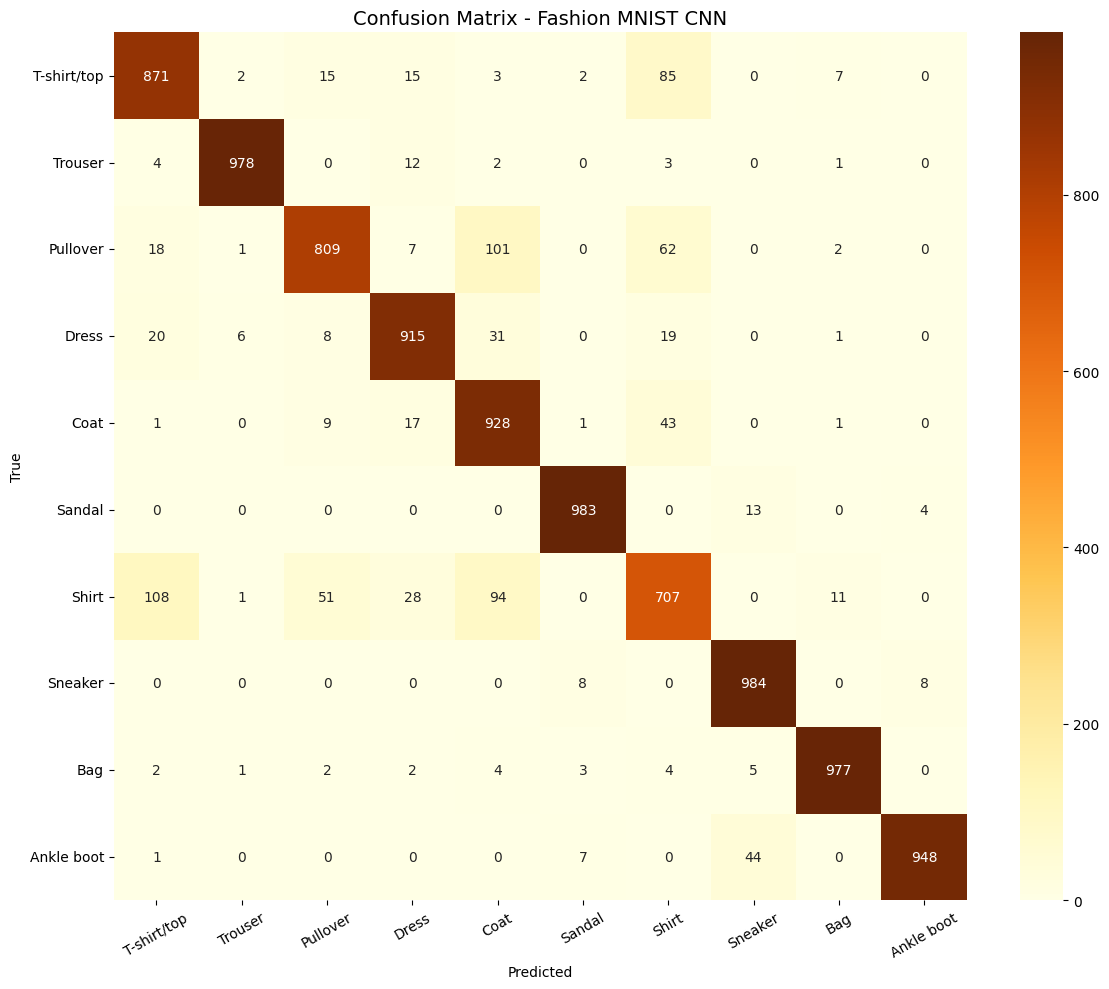

In [7]:
# BƯỚC 7: ĐÁNH GIÁ TRÊN TẬP TEST
score = model.evaluate(X_test, y_test_cat, verbose=2)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

y_pred = np.argmax(model.predict(X_test), axis=1)
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fashion MNIST CNN', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=30); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted: 9 - Ankle boot
True label: 9 - Ankle boot


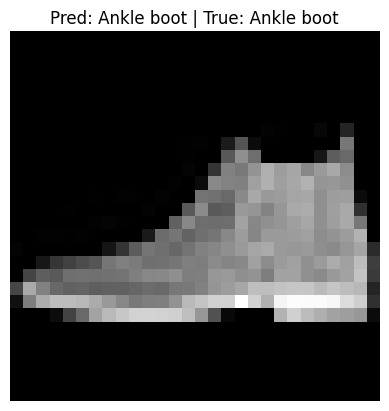

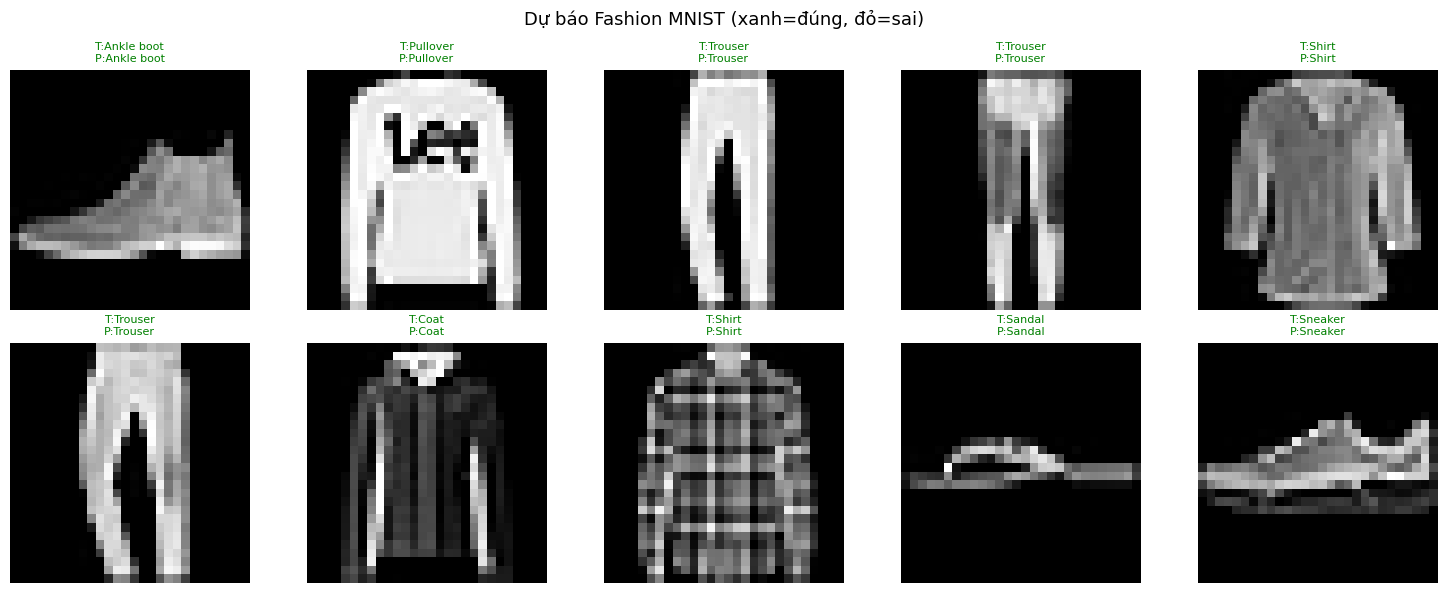

Đã lưu weights!


In [8]:
# BƯỚC 8: DỰ BÁO ẢNH MỚI + LƯU MODEL
predict = model.predict(X_test[:1])
print('Predicted:', np.argmax(predict), '-', class_names[np.argmax(predict)])
print('True label:', y_test[0], '-', class_names[y_test[0]])
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f'Pred: {class_names[np.argmax(predict)]} | True: {class_names[y_test[0]]}')
plt.axis('off'); plt.show()

# Hiển thị 10 kết quả
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    pred = np.argmax(model.predict(X_test[i:i+1], verbose=0))
    true = y_test[i]
    color = 'green' if pred == true else 'red'
    axes[i].imshow(X_test[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f'T:{class_names[true]}\nP:{class_names[pred]}', color=color, fontsize=8)
    axes[i].axis('off')
plt.suptitle('Dự báo Fashion MNIST (xanh=đúng, đỏ=sai)', fontsize=13)
plt.tight_layout(); plt.show()

model.save_weights('cnn_fashion.weights.h5')
print('Đã lưu weights!')